# 3D CNN Models — Hand Gesture Recognition

Two models trained directly on raw-pixel video clips from `clip_extraction.ipynb`:
1. **Model A** - a compact 3D CNN (Conv3D stack) trained from scratch
2. **Model B** - pretrained R(2+1)D-18 (Kinetics-400), fine-tuned

Both are evaluated with the shared `src/evaluation/metrics.py` module so results are
directly comparable to the landmark-based branche.


In [6]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.data.dataset import GESTURE_NAMES, NUM_CLASSES
from src.evaluation.metrics import full_evaluation, measure_inference_time, compare_models
from src.models.video_dataset import (
    GestureClipDataset, stratified_train_val_split, compute_class_weights,
    IMAGENET_MEAN, IMAGENET_STD, KINETICS_MEAN, KINETICS_STD,
)
from src.models.train_utils import get_device

CLIP_DIR = "../data/processed"

DEVICE = get_device()  # MPS > CUDA > CPU
print(f"Using device: {DEVICE}")

Using device: mps


## 1. Dataset & DataLoader

Stratified train/val split carved out of the train metadata only (test stays untouched,
official split). 

Class weights are computed from the train split for the weighted loss.

In [7]:
train_df, val_df = stratified_train_val_split(
    f"{CLIP_DIR}/train/_metadata.csv", val_frac=0.15, seed=42
)
print(f"Train: {len(train_df)}   Val: {len(val_df)}")

class_weights = compute_class_weights(train_df, num_classes=NUM_CLASSES)
print("\nClass weights (balanced: N / (num_classes * count)):")
for name, w in zip(GESTURE_NAMES, class_weights):
    print(f"  {name:14s} {w:.3f}")

Train: 2649   Val: 468

Class weights (balanced: N / (num_classes * count)):
  Point-1f       0.322
  Point-2f       0.323
  Click-1f       1.617
  Click-2f       1.617
  Throw-up       1.617
  Throw-down     1.617
  Throw-left     1.617
  Throw-right    1.617
  Open-twice     1.617
  DblClick-1f    1.630
  DblClick-2f    1.617
  Zoom-in        1.617
  Zoom-out       1.617


In [8]:
BATCH_SIZE = 8

# ImageNet stats for the from-scratch model (Model B will use its own
# Kinetics-normalized loaders).
train_ds = GestureClipDataset(train_df, mean=IMAGENET_MEAN, std=IMAGENET_STD, train=True)
val_ds = GestureClipDataset(val_df, mean=IMAGENET_MEAN, std=IMAGENET_STD, train=False)
test_ds = GestureClipDataset(f"{CLIP_DIR}/test/_metadata.csv", mean=IMAGENET_MEAN, std=IMAGENET_STD, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}   Val batches: {len(val_loader)}   Test batches: {len(test_loader)}")

Train batches: 332   Val batches: 59   Test batches: 138


## 2. Sanity check — inspect a batch

In [9]:
clips, labels = next(iter(train_loader))
print(f"Batch clips shape:  {clips.shape}")   # expect (B, 3, 16, 112, 112)
print(f"Batch labels shape: {labels.shape}")
print(f"dtype: {clips.dtype}, value range: [{clips.min():.3f}, {clips.max():.3f}]")
print(f"Labels: {labels.tolist()}")

Batch clips shape:  torch.Size([8, 3, 16, 112, 112])
Batch labels shape: torch.Size([8])
dtype: torch.float32, value range: [-2.118, 2.640]
Labels: [11, 0, 0, 3, 1, 1, 9, 9]


## 3. Visualize a clip — raw vs. augmented

Confirms the augmentation pipeline (flip / crop jitter / temporal jitter / color jitter)
is doing something reasonable.

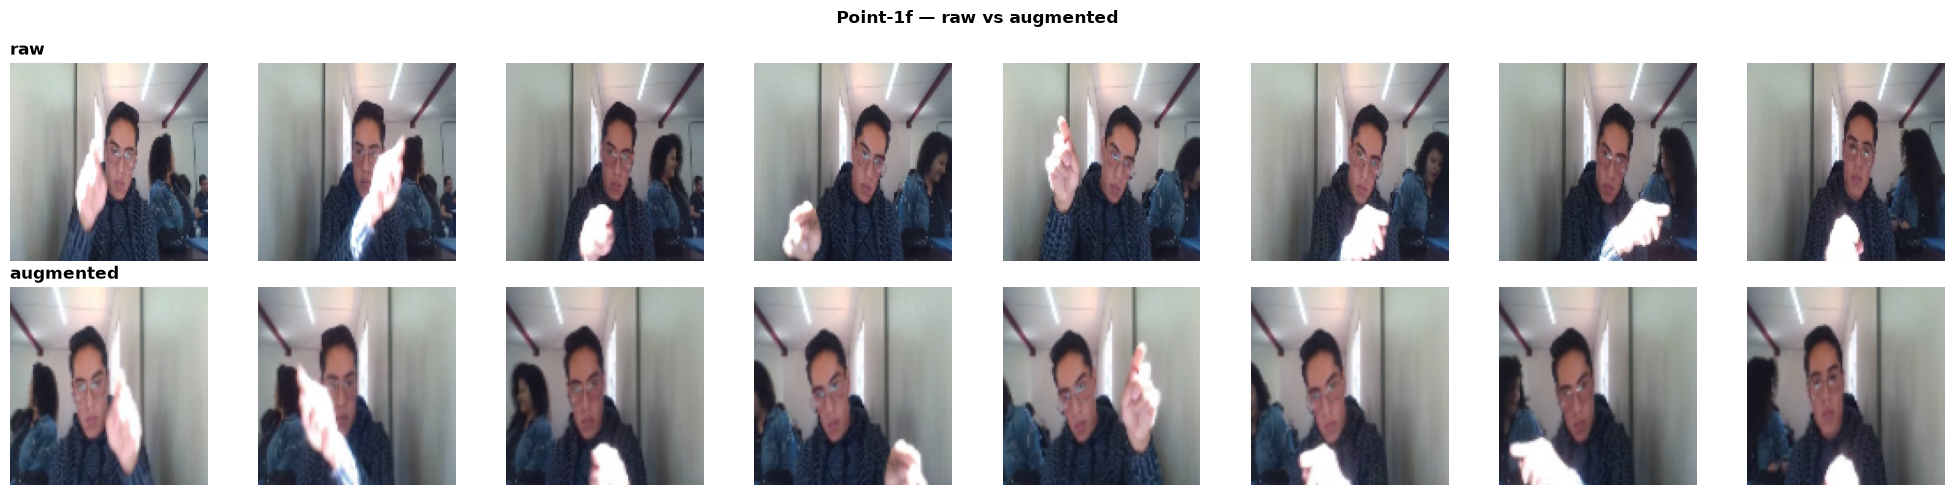

In [10]:
def denormalize(clip_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """(3, T, H, W) normalized tensor -> (T, H, W, 3) uint8 for display."""
    clip = clip_tensor.numpy() * std.reshape(3, 1, 1, 1) + mean.reshape(3, 1, 1, 1)
    clip = np.clip(clip, 0, 1)
    clip = np.transpose(clip, (1, 2, 3, 0))  # (T, H, W, 3)
    return (clip * 255).astype(np.uint8)


idx = 0
raw_clip = np.load(train_df.iloc[idx]['npy_path'])
aug_clip_t, label = train_ds[idx]
aug_clip = denormalize(aug_clip_t)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i in range(8):
    axes[0, i].imshow(raw_clip[i * 2]); axes[0, i].axis('off')
    axes[1, i].imshow(aug_clip[i * 2]); axes[1, i].axis('off')
axes[0, 0].set_title("raw", loc='left', fontweight='bold')
axes[1, 0].set_title("augmented", loc='left', fontweight='bold')
plt.suptitle(f"{train_df.iloc[idx]['gesture_name']} — raw vs augmented", fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Model A — 3D CNN from scratch

A compact Conv3D stack, kept small so it trains in reasonable time on MPS:

```
(3,16,112,112) → Conv3D(3→32)  + BN + ReLU + MaxPool3D(2)
               → Conv3D(32→64) + BN + ReLU + MaxPool3D(2)
               → Conv3D(64→128)+ BN + ReLU + MaxPool3D(2)
               → Conv3D(128→256)+BN + ReLU + AdaptiveAvgPool3D(1)
               → FC(256→128) + ReLU + Dropout(0.5) → FC(128→13)
```

In [11]:
from src.models.cnn3d import Simple3DCNN

model_a = Simple3DCNN(num_classes=NUM_CLASSES).to(DEVICE)

n_params = sum(p.numel() for p in model_a.parameters())
n_trainable = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f"Model A parameters: {n_params:,} total, {n_trainable:,} trainable")

# Forward-pass sanity check on a real batch, on-device.
clips, labels = next(iter(train_loader))
with torch.no_grad():
    logits = model_a(clips.to(DEVICE))
print(f"Input shape:  {clips.shape}")
print(f"Output shape: {logits.shape}")   # expect (B, 13)

Model A parameters: 1,199,821 total, 1,199,821 trainable
Input shape:  torch.Size([8, 3, 16, 112, 112])
Output shape: torch.Size([8, 13])


## 5. Training loop — Model A

- Weighted CrossEntropyLoss (class weights from step 1)
- Adam 
- ReduceLROnPlateau
- Early stopping on val loss (patience 10)

In [12]:
from src.models.train_utils import train_model, plot_history, predict

NUM_EPOCHS = 50
PATIENCE = 10

criterion_a = torch.nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
optimizer_a = torch.optim.Adam(model_a.parameters(), lr=1e-3)
scheduler_a = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_a, mode='min', factor=0.5, patience=4)

history_a, model_a = train_model(
    model_a, train_loader, val_loader, criterion_a, optimizer_a, DEVICE,
    num_epochs=NUM_EPOCHS, patience=PATIENCE, scheduler=scheduler_a,
    checkpoint_path="../data/checkpoints/model_a_scratch_best.pth",
    model_name="3DCNN_scratch",
)

[3DCNN_scratch] epoch   1/50 | train_loss 2.3640 acc 0.2488 | val_loss 2.2109 acc 0.3034 | 208.9s
[3DCNN_scratch] epoch   2/50 | train_loss 2.2614 acc 0.2563 | val_loss 2.1193 acc 0.3120 | 297.3s
[3DCNN_scratch] epoch   3/50 | train_loss 2.2205 acc 0.2771 | val_loss 2.1336 acc 0.2927 | 262.2s
[3DCNN_scratch] epoch   4/50 | train_loss 2.1893 acc 0.2839 | val_loss 2.1278 acc 0.2906 | 256.2s
[3DCNN_scratch] epoch   5/50 | train_loss 2.1455 acc 0.2790 | val_loss 2.1135 acc 0.2927 | 263.4s
[3DCNN_scratch] epoch   6/50 | train_loss 2.0951 acc 0.2854 | val_loss 1.9524 acc 0.3526 | 268.4s
[3DCNN_scratch] epoch   7/50 | train_loss 2.0596 acc 0.3069 | val_loss 1.9375 acc 0.3462 | 278.3s
[3DCNN_scratch] epoch   8/50 | train_loss 2.0240 acc 0.2945 | val_loss 1.9708 acc 0.3098 | 277.1s
[3DCNN_scratch] epoch   9/50 | train_loss 1.9822 acc 0.3133 | val_loss 2.1048 acc 0.2821 | 277.9s
[3DCNN_scratch] epoch  10/50 | train_loss 1.9468 acc 0.3228 | val_loss 1.7943 acc 0.3761 | 265.0s
[3DCNN_scratch] epoc

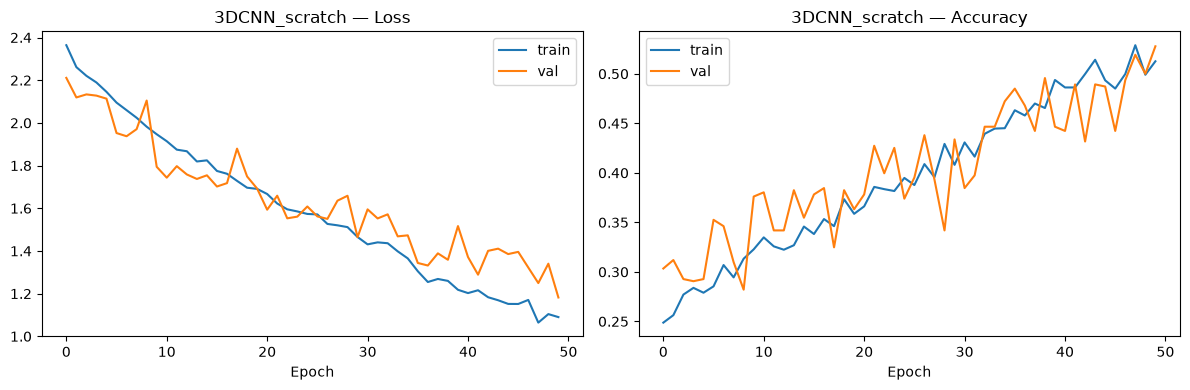

In [13]:
plot_history(history_a, "3DCNN_scratch")

## 6. Evaluate Model A on the test set


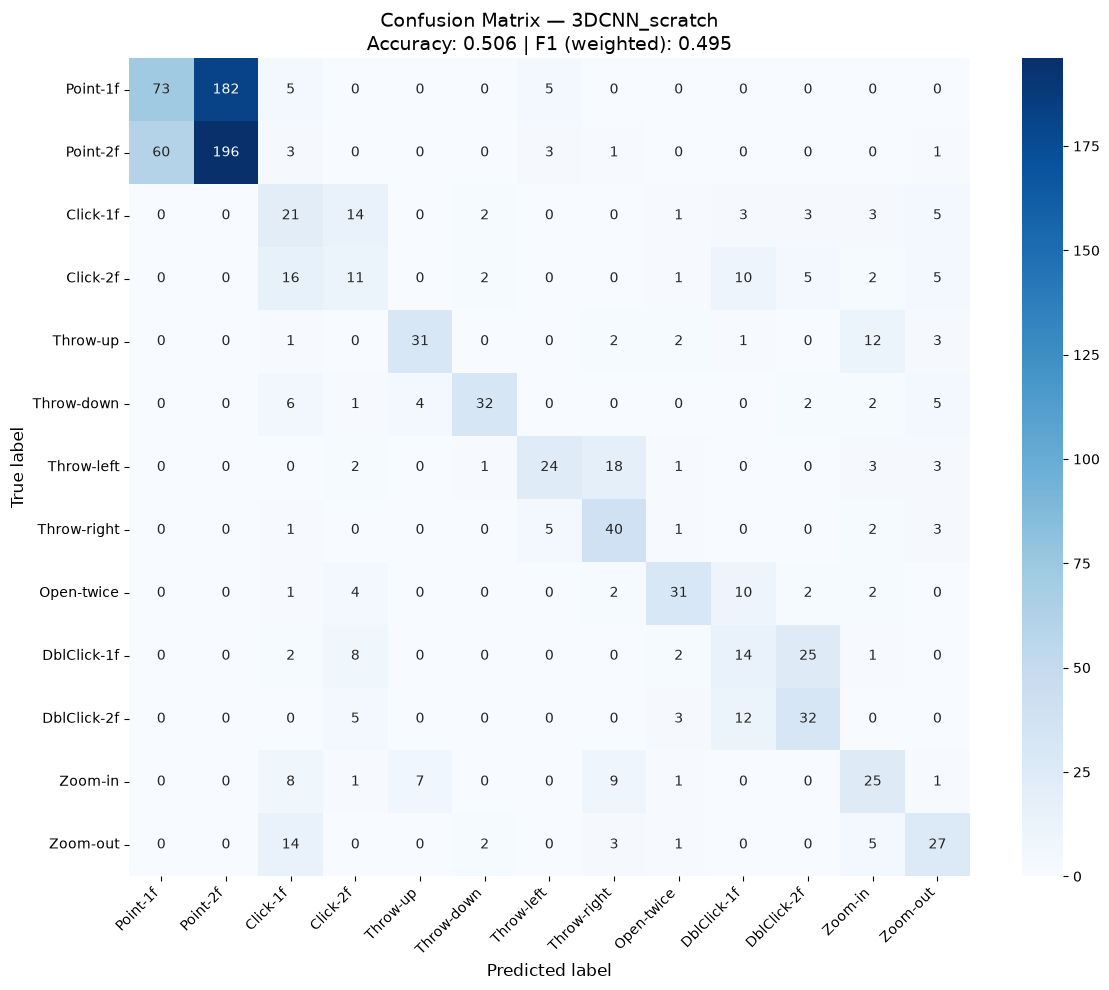

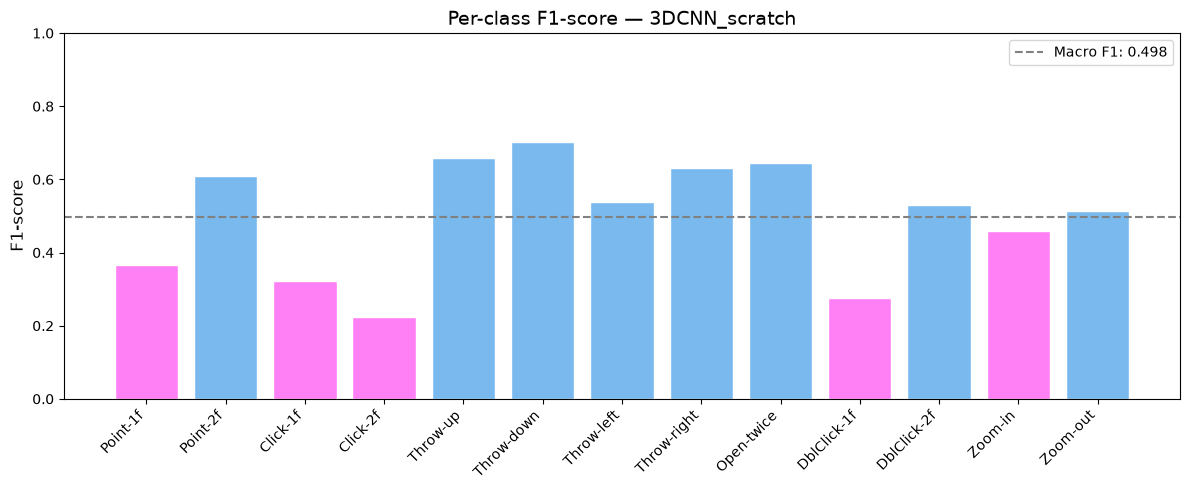


  3DCNN_scratch — Results
  Accuracy:          0.5059
  F1 (weighted):     0.4946
  F1 (macro):        0.4984
  Precision (w):     0.5231
  Recall (w):        0.5059
  Top-3 Accuracy:    0.9128
  Top-5 Accuracy:    0.9637

              precision    recall  f1-score   support

    Point-1f       0.55      0.28      0.37       265
    Point-2f       0.52      0.74      0.61       264
    Click-1f       0.27      0.40      0.32        52
    Click-2f       0.24      0.21      0.22        52
    Throw-up       0.74      0.60      0.66        52
  Throw-down       0.82      0.62      0.70        52
  Throw-left       0.65      0.46      0.54        52
 Throw-right       0.53      0.77      0.63        52
  Open-twice       0.70      0.60      0.65        52
 DblClick-1f       0.28      0.27      0.27        52
 DblClick-2f       0.46      0.62      0.53        52
     Zoom-in       0.44      0.48      0.46        52
    Zoom-out       0.51      0.52      0.51        52

    accuracy      

In [14]:
y_true_a, y_pred_a, y_prob_a = predict(model_a, test_loader, DEVICE)

results_a = full_evaluation(
    y_true_a, y_pred_a, "3DCNN_scratch",
    save_dir="../results/figures", y_prob=y_prob_a
)

In [15]:
from src.models.train_utils import count_parameters

def model_a_predict_fn(x):
    with torch.no_grad():
        return model_a(x)

sample_clip, _ = test_ds[0]
sample_clip = sample_clip.unsqueeze(0).to(DEVICE)  # (1, 3, 16, 112, 112)

timing_a = measure_inference_time(model_a_predict_fn, sample_clip, n_runs=100)
n_params_a, n_trainable_a = count_parameters(model_a)

print(f"Model A — {n_params_a:,} parameters")
print(f"Inference: {timing_a['mean_ms']:.2f} ± {timing_a['std_ms']:.2f} ms  ({timing_a['fps']:.1f} FPS)")

Model A — 1,199,821 parameters
Inference: 11.81 ± 19.51 ms  (84.7 FPS)


In [16]:
all_results = [results_a] 